In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ai_burnout_human_ai_collaboration.csv')

In [4]:
df.head()

,Worker_ID,Age,Industry,Job_Role,Years_Experience,AI_Tools_Used_Daily,AI_Hours_Per_Day,AI_Adoption_Level,Perceived_Usefulness,Skill_Anxiety_Score,...,Deep_Work_Hours,Interruptions_Per_Day,Sleep_Hours_Per_Night,Physical_Activity_Days,Stress_Level,Job_Satisfaction,Cognitive_Load_Score,Remote_Work_Ratio,Productivity_Score,Burnout_Label
0,1,22,Finance,Accountant,0.1,5,4.2,2,9,10,...,3.4,21,6.4,4,6,5,3,0.74,76.0,No Risk
1,2,29,Creative,Copywriter,9.7,5,3.4,2,10,2,...,3.6,7,5.6,2,5,8,4,0.24,72.9,No Risk
2,3,39,Education,Curriculum Designer,16.0,4,3.5,2,5,5,...,4.5,10,6.5,4,8,3,2,0.22,61.8,At Risk
3,4,29,Healthcare,Physician,5.5,6,3.2,2,6,3,...,3.7,11,6.4,4,2,6,2,0.11,85.1,No Risk
4,5,33,Technology,Product Manager,10.9,2,2.5,1,9,4,...,3.0,17,5.6,3,7,8,1,0.50,70.5,No Risk


In [24]:
# Convert Burnout_Label to numeric
df['Burnout_Numeric'] = df['Burnout_Label'].map({'No Risk':0, 'At Risk': 1, 'Burned Out': 2})   

print(df['Burnout_Numeric'].value_counts())

Burnout_Numeric
0    6601
1    1865
2      34
Name: count, dtype: int64


In [6]:
df.head()

,Worker_ID,Age,Industry,Job_Role,Years_Experience,AI_Tools_Used_Daily,AI_Hours_Per_Day,AI_Adoption_Level,Perceived_Usefulness,Skill_Anxiety_Score,...,Interruptions_Per_Day,Sleep_Hours_Per_Night,Physical_Activity_Days,Stress_Level,Job_Satisfaction,Cognitive_Load_Score,Remote_Work_Ratio,Productivity_Score,Burnout_Label,Burnout_Numeric
0,1,22,Finance,Accountant,0.1,5,4.2,2,9,10,...,21,6.4,4,6,5,3,0.74,76.0,No Risk,0.0
1,2,29,Creative,Copywriter,9.7,5,3.4,2,10,2,...,7,5.6,2,5,8,4,0.24,72.9,No Risk,0.0
2,3,39,Education,Curriculum Designer,16.0,4,3.5,2,5,5,...,10,6.5,4,8,3,2,0.22,61.8,At Risk,1.0
3,4,29,Healthcare,Physician,5.5,6,3.2,2,6,3,...,11,6.4,4,2,6,2,0.11,85.1,No Risk,0.0
4,5,33,Technology,Product Manager,10.9,2,2.5,1,9,4,...,17,5.6,3,7,8,1,0.50,70.5,No Risk,0.0


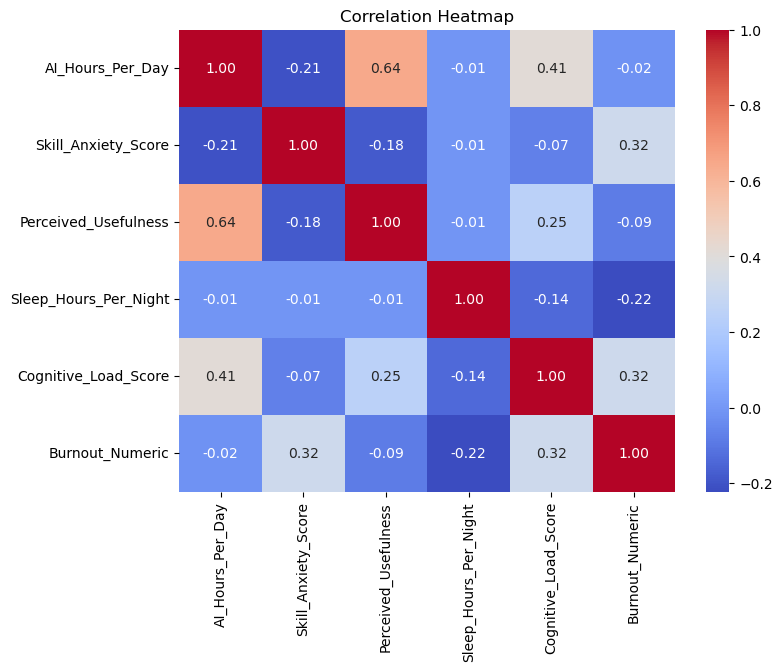

In [26]:
# Correlation heatmap between AI hour use, Sleep, Cognitive load, Replacement Anxiety and Burnout risk
correlation_matrix = df[['AI_Hours_Per_Day', 'Skill_Anxiety_Score', 'Perceived_Usefulness','Sleep_Hours_Per_Night' , 'Cognitive_Load_Score', 'Burnout_Numeric']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# While AI is perceived as useful (r=0.64 with AI hours per day), it is also positively correlated with cognitive load (r=0.41),
# which could be a primary driver of burnout risk (r=0.32).
# Higher AI usage is also negatively correlated with replacement anxiety (r=-0.21), suggesting that hands-on experience may demystifies 
# the technology and reduce anxiety about being replaced by it.
# Replacement anxiety seems to be a stronger predictor of burnout risk than AI hours per day, suggesting that 
# the psychological fear of AI may be more important than the actual usage in contributing to burnout risk.
# Sleep hours are negatively correlated with burnout risk (r=-0.22), suggesting sleep could be a 'buffer' against burnout.

In [ ]:
# Explore whether usefulness moderates the relationship between anxiety and burnout risk

In [48]:
# Create a "High Usefulness" and "Low Usefulness" group (using the median as a split)
median_use = df['Perceived_Usefulness'].median()
High_Use = df[df['Perceived_Usefulness'] >= median_use]
Low_Use = df[df['Perceived_Usefulness'] < median_use]

# Check how Anxiety correlates with Burnout in BOTH groups
corr_high = High_Use['Skill_Anxiety_Score'].corr(High_Use['Burnout_Numeric'])
corr_low = Low_Use['Skill_Anxiety_Score'].corr(Low_Use['Burnout_Numeric'])

print(f"Anxiety -> Burnout Correlation (When Usefulness is HIGH): {corr_high:.2f}")
print(f"Anxiety -> Burnout Correlation (When Usefulness is LOW): {corr_low:.2f}")

Anxiety -> Burnout Correlation (When Usefulness is HIGH): 0.30
Anxiety -> Burnout Correlation (When Usefulness is LOW): 0.33


In [ ]:
# AI anxiety works the same way regardless of whether the AI is perceived as useful or not, suggesting that the psychological fear of AI may be a consistent driver of burnout risk independent of how useful the AI is perceived to be.

In [ ]:
# Perceived usefulness seems to be two independent

In [ ]:
## Understanding whether the relationship between replacement anxiety and burnout risk differs by career stage (junior vs expert)

/var/folders/js/sp_c_k3n3936x6kyg31vxn8r0000gn/T/ipykernel_82695/2983978294.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_analysis = df.groupby('Career_Phase')['Skill_Anxiety_Score'].mean()
/var/folders/js/sp_c_k3n3936x6kyg31vxn8r0000gn/T/ipykernel_82695/2983978294.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phase_analysis.index, y=phase_analysis.values, palette='viridis')


Career_Phase
Early Career    6.466776
Mid-Level       4.686951
Senior          4.220971
Veteran         3.926214
Name: Skill_Anxiety_Score, dtype: float64


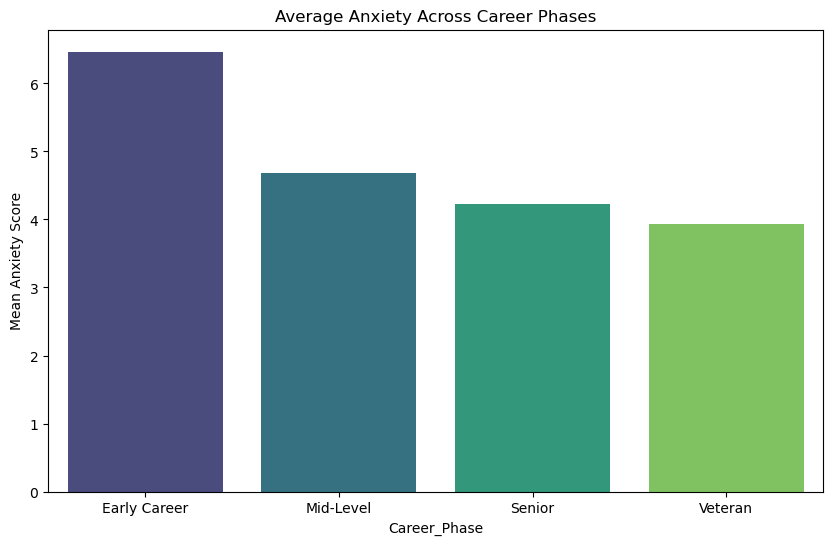

In [28]:
# See whether years of experience moderate the relationship between anxiety and burnout
# Create 4 career phases
df['Career_Phase'] = pd.cut(df['Years_Experience'], 
                            bins=[0, 5, 10, 20, 40], 
                            labels=['Early Career', 'Mid-Level', 'Senior', 'Veteran'])

# Average Anxiety for each phase
phase_analysis = df.groupby('Career_Phase')['Skill_Anxiety_Score'].mean()
print(phase_analysis)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_analysis.index, y=phase_analysis.values, palette='viridis')
plt.title('Average Anxiety Across Career Phases')
plt.ylabel('Mean Anxiety Score')
plt.show()

In [10]:
# Descriptives showed that people in early career stage (0-5 years) had the highest AI replacement anxiety, could be 
# explained by the fact that they are new in building their professional identity and they don't have as much 
# instituional knowledge or expertise in their field of work yet

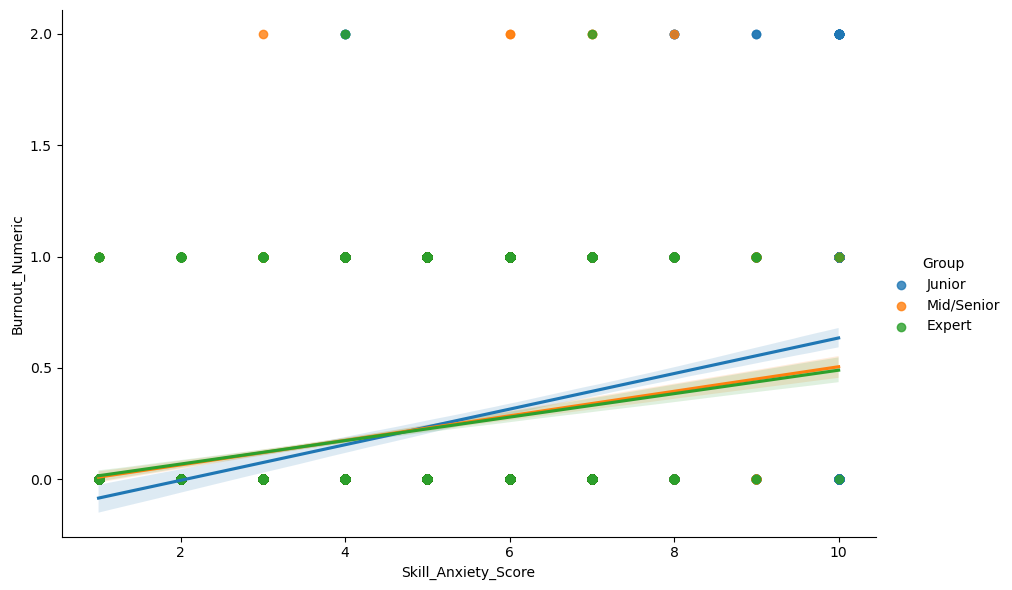

In [29]:
df['Group'] = 'Mid/Senior'

df.loc[df['Years_Experience'] < 5, 'Group'] = 'Junior'
df.loc[df['Years_Experience'] >= 15, 'Group'] = 'Expert'


sns.lmplot(
    data=df,
    x='Skill_Anxiety_Score',
    y='Burnout_Numeric',
    hue='Group', # Color points and regression lines by 'Condition'
    # col='Condition', # Alternatively, use 'col' to create separate plots for each condition
    height= 6, 
    aspect=1.5
)

In [30]:
# Correlation calculations for junior and expert groups

Junior = df[df['Years_Experience'] < 5]
Expert = df[df['Years_Experience'] >= 5]

print(f" Junior Correlation: {Junior['Skill_Anxiety_Score'].corr(Junior['Burnout_Numeric']): .2f}")
print(f" Expert Correlation: {Expert['Skill_Anxiety_Score'].corr(Expert['Burnout_Numeric']): .2f}")

 Junior Correlation:  0.35
 Expert Correlation:  0.22


In [ ]:
# While AI adoption is universal, its psychological impact is highly asymmetrical. While early-career employees (Juniors) report
# lower baseline burnout at low anxiety levels, they exhibit a visibly steeper burnout-response slope (r=0.35) compared with Veterans (r=0.22).
# At low anxiety levels, Juniors are the least burned-out group. However, once AI-replacement anxiety scores exceed 4/5, Juniors become the most burned-out group, 
# suggesting they are more vulnerable to AI-induced burnout as their career identity is still forming and more malleable.
# This suggests that Juniors may require identity-anchoring interventions to prevent rapid burnout as AI adoption increases, 
# whereas Experts may benefit more from general stress or workload management, as their burnout is less tied to specific AI skill-fear


In [ ]:
# So far, we have seen that sleep might buffer burnout risk, and AI replacement anxiety is positively associated with burnout risk, and this relationship is moderated by career stage.
# Next, let's see how much each variable actually matters in predicting burnout risk.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features and target variable
features = ['Age', 'Years_Experience', 'AI_Hours_Per_Day', 
    'Skill_Anxiety_Score', 'Perceived_Usefulness', 
    'Sleep_Hours_Per_Night', 'Cognitive_Load_Score']

X = df[features]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Forest with 'balanced' weights for your small 'High Risk' group
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# 4. Predict and Score
y_pred = rf.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1317
           1       0.63      0.35      0.45       375
           2       0.00      0.00      0.00         8

    accuracy                           0.81      1700
   macro avg       0.49      0.43      0.45      1700
weighted avg       0.79      0.81      0.79      1700



In [ ]:
# Class 2 has a recall of 0 because even with class_weight='balanced', the model is still struggling to identify the few ]
# 'High Risk' cases, likely due to the extreme imbalance and small sample size in that category. This highlights the need for 
# more data collection or a synthetic oversamplingor alternative modeling approaches to better capture the 'High Risk' group.
# Our RF model reveals that cognitive load is the primary predictor of burnout: while employees find AI useful, the 'mental tax' of
# managing AI outputs is a stronger driver of burnout (0.2 importance) than the fear of being repalced (0.13) 
# Years of experience is the second most powerful feature, validating that career stage is a primary driver of burnout variance. 
# When paired with our previous regression analysis, we see this is because early-career employees are more vulnerable to AI-induced burnout as their career identity is still forming and more malleable.
# To protect talent, companies shouldn't just focus on "AI training", but also need to provide support for managing cognitive load and mental health, 
# especially for early-career employees who are more vulnerable to AI-induced burnout.

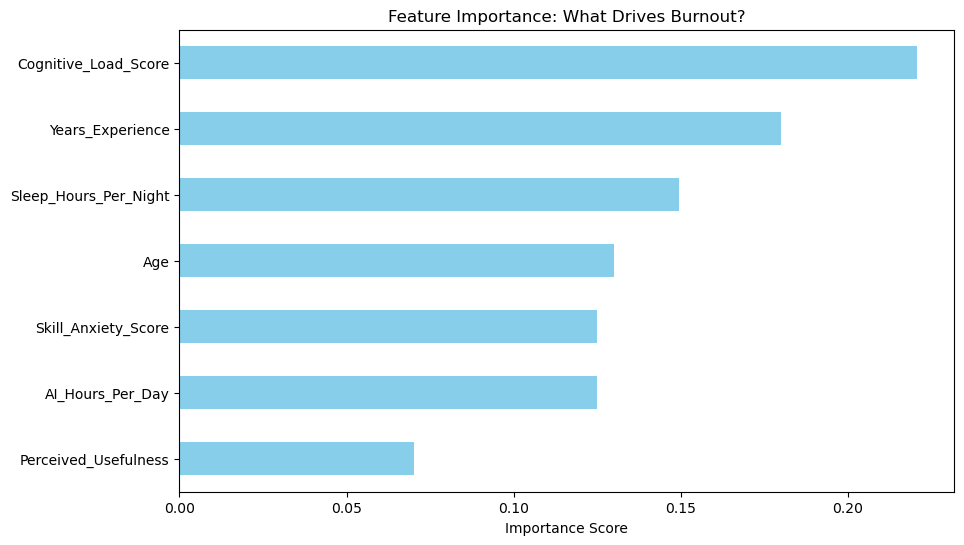

In [42]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance: What Drives Burnout?')
plt.xlabel('Importance Score')
plt.show()

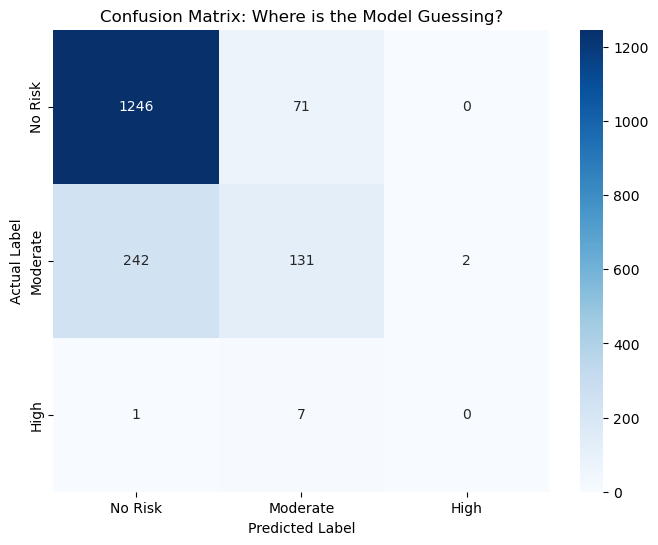

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Risk', 'Moderate', 'High'], 
            yticklabels=['No Risk', 'Moderate', 'High'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix: Where is the Model Guessing?')
plt.show()

In [ ]:
## Since AI hours and perceived usefulness has a fairly strong correlation (0.64) with each other, I've decided to exclude 
# perceived usefulness (having the least importance score from RF model) from the model to avoid multicollinearity issues and better isolate the unique contribution of AI hours on burnout risk.


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features and target variable
features = ['Age', 'Years_Experience', 'AI_Hours_Per_Day', 
    'Skill_Anxiety_Score', 'Sleep_Hours_Per_Night', 'Cognitive_Load_Score']

X = df[features]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Forest with 'balanced' weights for your small 'High Risk' group
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# 4. Predict and Score
y_pred = rf.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1317
           1       0.61      0.35      0.44       375
           2       0.50      0.12      0.20         8

    accuracy                           0.81      1700
   macro avg       0.65      0.47      0.51      1700
weighted avg       0.78      0.81      0.78      1700



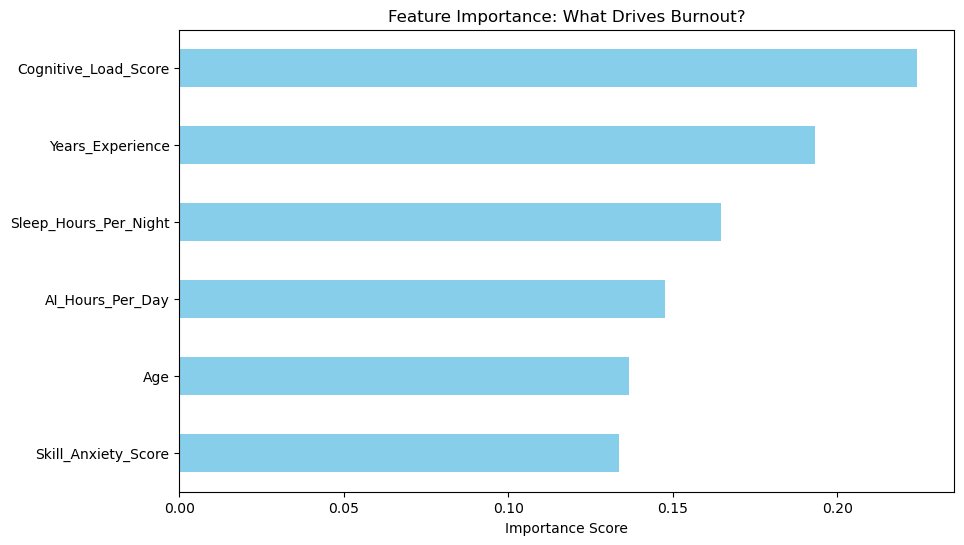

In [45]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance: What Drives Burnout?')
plt.xlabel('Importance Score')
plt.show()

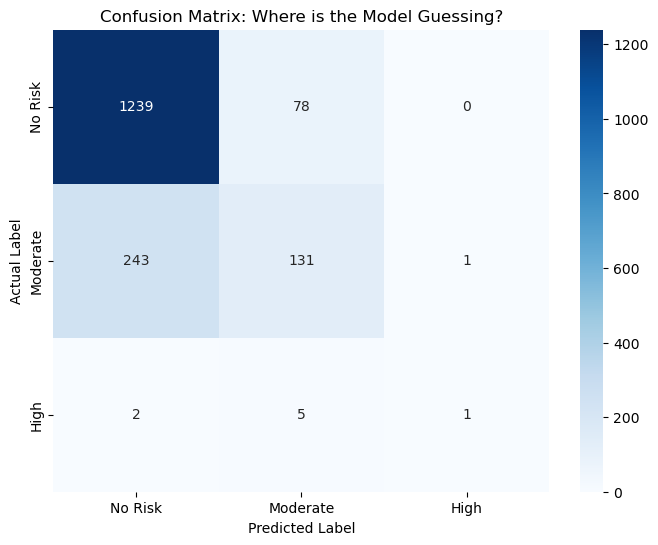

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Risk', 'Moderate', 'High'], 
            yticklabels=['No Risk', 'Moderate', 'High'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix: Where is the Model Guessing?')
plt.show()

In [ ]:
# Cognitive load remains the greatest predictor of burnout risk. It's not the tool but the mental tax of the workflow.
# Career stage (years of experience) dictates the vulnerability to AI-induced burnout, with early-career employees being more vulnerable as their professional identity is still forming and more malleable.
# Sleep is the primary physical buffer against workplace burnout.
# Actual time spent in AI becomes a primary secondary-predictor once psychological perceptions of AI are accounted for, suggesting that the behavioral engagement with AI is a more powerful predictor of burnout risk than subjective perceptions of AI.

In [ ]:
# by removing perceived usefulness, the model's ability to see the high-risk cases improved slightly (from 0 to 0.12), suggesting that the multicollinearity between AI hours and perceived usefulness was indeed obscuring the unique contribution of AI hours in predicting burnout risk.
# Through iterative feature selection, we reduced model copmlexity by removing redundant features. This model maintained an overall 81% accuracy while improving recall for the critical 'High Risk' group, demonstrating that behavioral data (AI hours) and biological markers (sleep) are more powerful predictors of burnout risk than subjective perceptions of AI, and that multicollinearity can obscure the true importance of features in predictive modeling.

<Figure size 640x480 with 0 Axes>